In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from numpy import linalg as LA

In [3]:
#Model parameters

c1 = 0.5
xi = 8.5
q_c = 7
q_e = 0.093
tau_q = 15
T_mean = 16.6
alpha_q = q_c*q_e*np.exp(q_e*T_mean)/tau_q
gamma = 5.6
chi_A = 0.31
chi_O = 1.38

Q_mean = 0.9

dA = 0.1
dO = 0.5

re = 0.5
rw = 0.5

a = chi_O*c1*gamma
b = c1*xi*alpha_q

Q1 =  chi_A*alpha_q/(2 - 2*Q_mean)
Q2 =  chi_A*alpha_q/(3 - 3*Q_mean)

mu = 0.04

LO = 6/5
LA = 8/3

NO = 168


xO = np.linspace(0,LO,NO)
dxO = xO[1] - xO[0]

#t_f = 3*9.6
#t_N = 3*960


t_f = 2*9.6
t_N = 3*960

t = np.linspace(0,t_f,t_N)
dt = t[1] - t[0]

eta = 1.5 + (0.5*np.tanh(7.5*(xO - LO/2)))

In [4]:
ENSO_Model = scipy.io.loadmat('Coupled_NonLinear_1_2.mat')
KA = ENSO_Model['Kelvin_Atmosphere']
RA = ENSO_Model['Rossby_Atmosphere']
KO = ENSO_Model['Kelvin_Ocean']
RO = ENSO_Model['Rossby_Ocean']
T = ENSO_Model['Temperature']

#Numerical simulations
#KA = KA[960:,:]
#RA = RA[960:,:]
#KO = KO[960:,:]
#RO = RO[960:,:]
#T = T[960:,:]

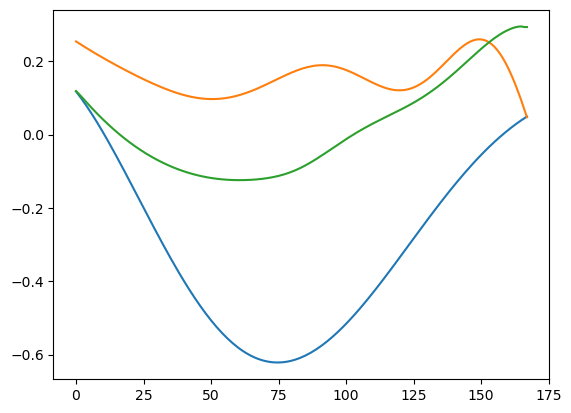

In [5]:
plt.plot(KO[0,:])
plt.plot(RO[0,:])
plt.plot(T[0,:])

In [6]:
N = 4

In [7]:

KA_2 = KA -  np.mean(KA,axis=0)
RA_2 =  RA -  np.mean(RA,axis=0)
KO_2 = KO -  np.mean(KO,axis=0)
RO_2 =  RO -  np.mean(RO,axis=0)
T_2 = T -  np.mean(T,axis=0)

tau = 1

t_N_S = (int((t_N)/tau))

#Snapshots
KA_S = np.zeros((t_N_S,NO))
RA_S = np.zeros((t_N_S,NO))
KO_S = np.zeros((t_N_S,NO))
RO_S = np.zeros((t_N_S,NO))
T_S = np.zeros((t_N_S,NO))

for k in range(0, t_N_S):
    KA_S[k,:] = KA_2[tau*k,:] 
    RA_S[k,:]= RA_2[tau*k,:] 
    KO_S[k,:] = KO_2[tau*k,:] 
    RO_S[k,:]= RO_2[tau*k,:] 
    T_S[k,:] = T_2[tau*k,:] 
    
    
d_KA_S = np.zeros([t_N_S, NO])
d_RA_S = np.zeros([t_N_S, NO])
d_KO_S = np.zeros([t_N_S, NO])
d_RO_S = np.zeros([t_N_S, NO])
d_T_S = np.zeros([t_N_S, NO])

for k in range(t_N_S):
    d_KA_S[k,:] = np.gradient(KA_S[k,:],xO) 
    d_RA_S[k,:] = np.gradient(RA_S[k,:],xO) 
    d_KO_S[k,:] = np.gradient(KO_S[k,:],xO) 
    d_RO_S[k,:] = np.gradient(RO_S[k,:],xO) 
    d_T_S[k,:] = np.gradient(T_S[k,:],xO)   
    
C_KA = np.zeros([t_N_S, t_N_S])
C_RA = np.zeros([t_N_S, t_N_S])
C_KO = np.zeros([t_N_S, t_N_S])
C_RO = np.zeros([t_N_S, t_N_S])
C_T = np.zeros([t_N_S, t_N_S])


d_C_KA = np.zeros([t_N_S, t_N_S])
d_C_RA = np.zeros([t_N_S, t_N_S])
d_C_KO = np.zeros([t_N_S, t_N_S])
d_C_RO = np.zeros([t_N_S, t_N_S])
d_C_T = np.zeros([t_N_S, t_N_S])

C_KA = np.matmul(KA_S, KA_S.T)
C_RA = np.matmul(RA_S, RA_S.T)
C_KO = np.matmul(KO_S, KO_S.T)
C_RO = np.matmul(RO_S, RO_S.T)
C_T = np.matmul(T_S, T_S.T)


d_C_KA = np.matmul(d_KA_S, d_KA_S.T)
d_C_RA = np.matmul(d_RA_S, d_RA_S.T)
d_C_KO = np.matmul(d_KO_S, d_KO_S.T)
d_C_RO = np.matmul(d_RO_S, d_RO_S.T)
d_C_T = np.matmul(d_T_S, d_T_S.T)

#C_KA_H1 = C_KA/t_N_S + eps*d_C_KA/t_N_S
#C_RA_H1 = C_RA/t_N_S + eps*d_C_RA/t_N_S
#C_KO_H1 = C_KO/t_N_S + eps*d_C_KO/t_N_S
#C_RO_H1 = C_RO/t_N_S + eps*d_C_RO/t_N_S
#C_T_H1 = C_T/t_N_S + eps*d_C_T/t_N_S

phi_KA = np.zeros([N, NO])
phi_RA = np.zeros([N, NO])
phi_KO = np.zeros([N, NO])
phi_RO = np.zeros([N, NO])
phi_T = np.zeros([N, NO])

d_phi_KA = np.zeros([N, NO])
d_phi_RA = np.zeros([N, NO])
d_phi_KO = np.zeros([N, NO])
d_phi_RO = np.zeros([N, NO])
d_phi_T = np.zeros([N, NO])

dd_phi_KA = np.zeros([N, NO])
dd_phi_RA = np.zeros([N, NO])
dd_phi_KO = np.zeros([N, NO])
dd_phi_RO = np.zeros([N, NO])
dd_phi_T = np.zeros([N, NO])

In [8]:
C_KA = np.matmul(KA_S, KA_S.T)
C_RA = np.matmul(RA_S, RA_S.T)
C_KO = np.matmul(KO_S, KO_S.T)
C_RO = np.matmul(RO_S, RO_S.T)
C_T = np.matmul(T_S, T_S.T)

In [9]:
eps = 0

In [10]:
C_H1 = (C_KO + C_RO + C_T)/t_N_S + eps*(d_C_KO + d_C_RO + d_C_T )/t_N_S

In [11]:
from numpy import linalg as LA
eig, y = LA.eig(C_H1)

In [12]:
eig[:8]

array([1.70554586e+01+0.j, 6.68081254e+00+0.j, 4.97504693e-02+0.j,
       2.18929156e-02+0.j, 2.17290553e-04+0.j, 1.35764852e-04+0.j,
       4.43202985e-05+0.j, 1.68068577e-05+0.j])

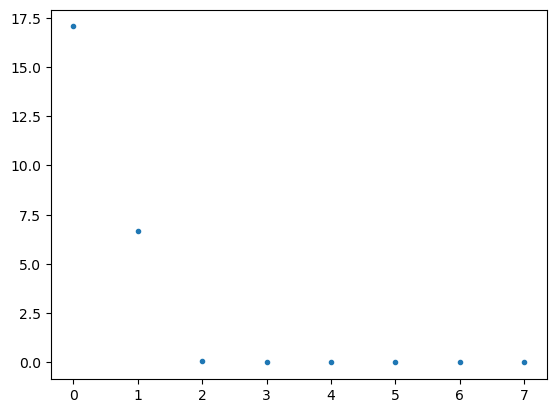

In [13]:
plt.plot(np.real(eig[:8]),'.')

##POD

In [14]:
for k in range(N):
    for i in range(t_N_S):
        phi_KA[k,:] += (np.real(y[i,k]))*KA_S[i,:]/np.sqrt(t_N_S*np.real(eig[k]))
        phi_RA[k,:] += (np.real(y[i,k]))*RA_S[i,:]/np.sqrt(t_N_S*np.real(eig[k]))
        phi_KO[k,:] += (np.real(y[i,k]))*KO_S[i,:]/np.sqrt(t_N_S*np.real(eig[k]))
        phi_RO[k,:] += (np.real(y[i,k]))*RO_S[i,:]/np.sqrt(t_N_S*np.real(eig[k]))
        phi_T[k,:] += (np.real(y[i,k]))*T_S[i,:]/np.sqrt(t_N_S*np.real(eig[k]))

In [15]:
for k in range(0,N):
    d_phi_KA[k,:] = np.gradient(phi_KA[k,:],xO, edge_order=2)
    d_phi_RA[k,:] = np.gradient(phi_RA[k,:],xO, edge_order=2)
    d_phi_KO[k,:] = np.gradient(phi_KO[k,:],xO, edge_order=2)
    d_phi_RO[k,:] = np.gradient(phi_RO[k,:],xO, edge_order=2)
    d_phi_T[k,:] = np.gradient(phi_T[k,:],xO, edge_order=2)

In [16]:
for k in range(0,N):
    dd_phi_KA[k,:] = np.gradient(d_phi_KA[k,:],xO, edge_order=2)
    dd_phi_RA[k,:] = np.gradient(d_phi_RA[k,:],xO, edge_order=2)
    dd_phi_KO[k,:] = np.gradient(d_phi_KO[k,:],xO, edge_order=2)
    dd_phi_RO[k,:] = np.gradient(d_phi_RO[k,:],xO, edge_order=2)
    dd_phi_T[k,:] = np.gradient(d_phi_T[k,:],xO, edge_order=2)

In [17]:
Psi = np.zeros([3*NO,N])
for i in range(N):
    for k in range(NO):
        Psi[k,i] = phi_KO[i,k]
        Psi[k+NO, i] = phi_RO[i,k]
        Psi[k+2*NO, i] = phi_T[i,k]

In [18]:
d_Psi = np.zeros([3*NO,N])
for i in range(N):
    for k in range(NO):
        d_Psi[k,i] = d_phi_KO[i,k]
        d_Psi[k+NO, i] = d_phi_RO[i,k]
        d_Psi[k+2*NO, i] = d_phi_T[i,k]

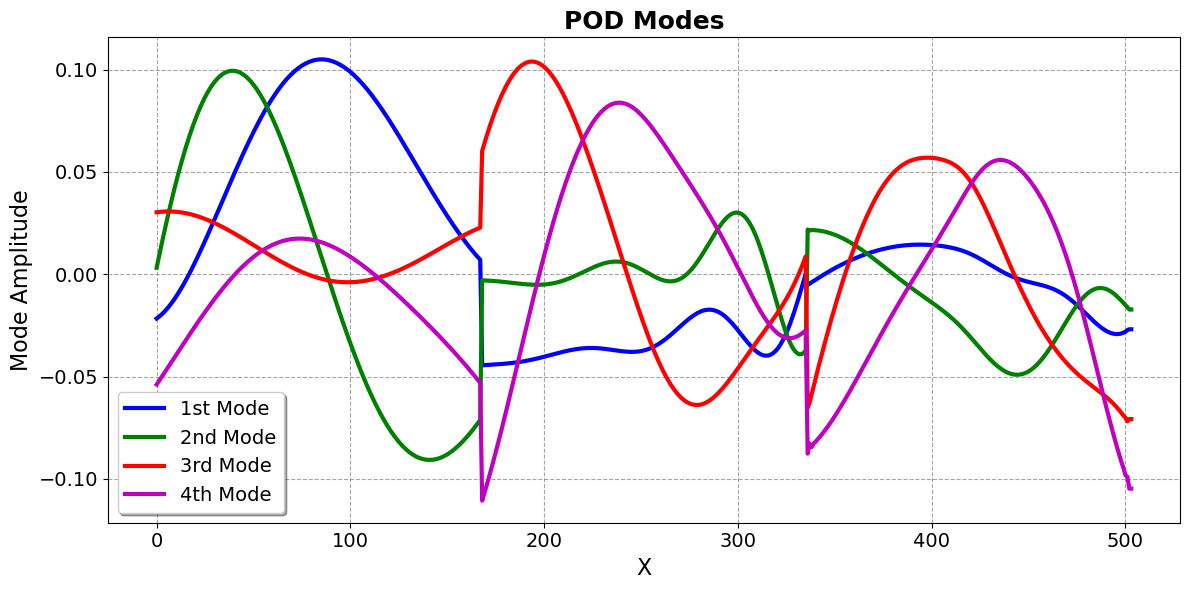

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Example data (replace with your actual data)
# Psi = np.random.rand(100, 4)  # Example data for demonstration

plt.figure(figsize=(12, 6))

# Plotting each mode with different line styles and colors
plt.plot(Psi[:, 0], label='1st Mode', linestyle='-', color='b', linewidth=3)
plt.plot(Psi[:, 1], label='2nd Mode', linestyle='-', color='g', linewidth=3)
plt.plot(Psi[:, 2], label='3rd Mode', linestyle='-', color='r', linewidth=3)
plt.plot(Psi[:, 3], label='4th Mode', linestyle='-', color='m', linewidth=3)

# Adding title and labels
plt.title('POD Modes', fontsize=18, fontweight='bold')
plt.xlabel('X', fontsize=16)
plt.ylabel('Mode Amplitude', fontsize=16)

# Adding grid with specific styling
plt.grid(True, linestyle='--', color='gray', alpha=0.7)

# Adding a legend with a shadow and fancy box
plt.legend(fontsize=14, loc='lower left', shadow=True, fancybox=True)

# Adding annotations for better clarity
#for i, label in enumerate(['1st Mode', '2nd Mode', '3rd Mode', '4th Mode']):
#    plt.text(len(Psi)//2, Psi[:, i][-1], label, color=['b', 'g', 'r', 'm'][i], fontsize=14, ha='right')

# Adjusting tick parameters for better readability
plt.tick_params(axis='both', which='major', labelsize=14)

# Show plot
plt.tight_layout()

# Save the plot if needed
plt.savefig("Psi_Modes_Plot.png", dpi=300)
plt.show()


In [20]:
for k in range(N):
    print(np.inner(Psi[:,k], Psi[:,k]) + eps*np.inner(d_Psi[:,k],d_Psi[:,k])) 

1.0000000000000009
0.9999999999999989
0.9999999999999962
0.9999999999999929


In [21]:
for k in range(N-1):
    print(np.inner(Psi[:,k], Psi[:,k+1])+ eps*np.inner(d_Psi[:,k],d_Psi[:,k+1]))

2.7484525072507537e-16
1.2802259252708836e-15
-5.27529409044547e-15


In [22]:
q = np.zeros([t_N_S,N])

In [23]:
for k in range(N):
    q[:,k] = np.sqrt(t_N_S*np.real(eig[k]))*np.real(y[:,k])

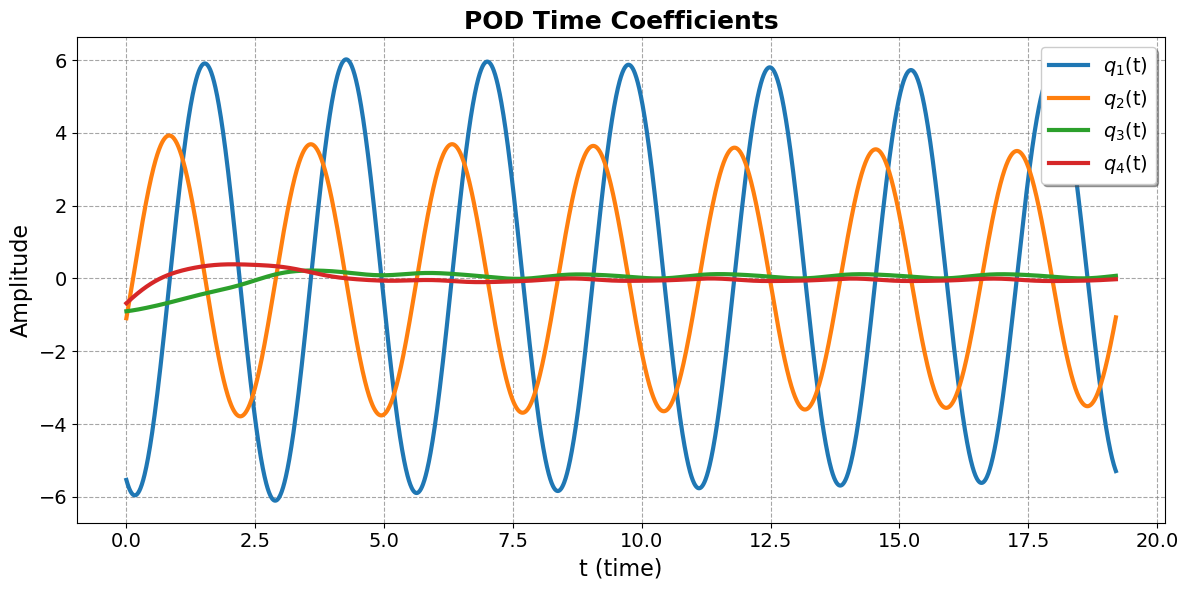

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Example data
# N = 5  # Number of modes for demonstration
# q = np.random.rand(100, N)  # Example data for demonstration

plt.figure(figsize=(12, 6))

# Loop to plot each mode with different styles
for k in range(0, N):
    plt.plot(t,q[:, k], label=f'$q_{k+1}$(t)', linewidth=3, markersize=6)

# Adding title and labels
plt.title('POD Time Coefficients', fontsize=18, fontweight='bold')
plt.xlabel('t (time)', fontsize=16)
plt.ylabel('Amplitude', fontsize=16)

# Adding a grid with specific styling
plt.grid(True, linestyle='--', color='gray', alpha=0.7)

# Adding a legend with a shadow and fancy box
plt.legend(fontsize=14, loc='upper right', shadow=True, fancybox=True)

# Adding annotations for better clarity
#for k in range(0, N):
#    plt.text(len(q) - 1, q[-1, k], f'Mode {k+1}', color=plt.gca().get_lines()[k].get_color(), fontsize=10, ha='left')

# Adjusting tick parameters for better readability
plt.tick_params(axis='both', which='major', labelsize=14)

# Show plot
plt.tight_layout()

# Save the plot if needed
plt.savefig("POD_q_Plot.png", dpi=300)
plt.show()



In [25]:
KA_R = np.matmul(q, phi_KA)
RA_R = np.matmul(q, phi_RA)
KO_R = np.matmul(q, phi_KO)
RO_R = np.matmul(q, phi_RO)
T_R = np.matmul(q, phi_T) 

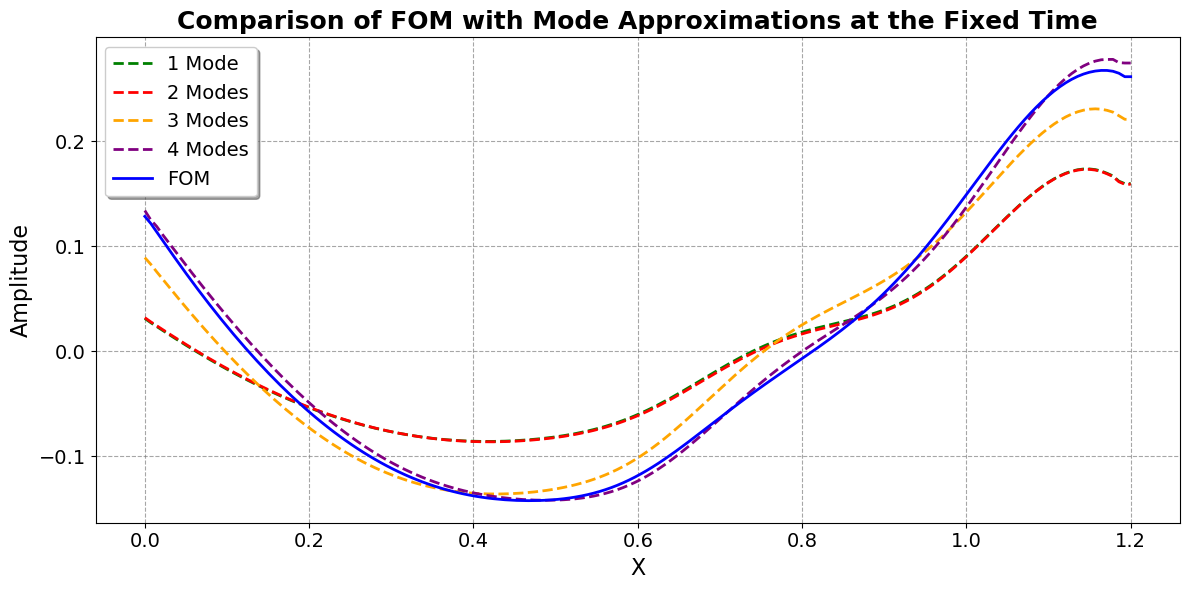

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Example data (replace with your actual data)
# T = np.random.rand(50, 5)  # Example data for demonstration
# q = np.random.rand(50, 5)  # Example data for demonstration
# phi_T = np.random.rand(5, 50)  # Example data for demonstration

plt.figure(figsize=(12, 6))



# Plot 1 Mode
plt.plot(xO,np.matmul(q[:, :1], phi_T[:1, :])[20, :], '--', label='1 Mode', color='green', linewidth=2)

# Plot 2 Modes
plt.plot(xO,np.matmul(q[:, :2], phi_T[:2, :])[20, :], '--', label='2 Modes', color='red', linewidth=2)

# Plot 3 Modes
plt.plot(xO,np.matmul(q[:, :3], phi_T[:3, :])[20, :], '--', label='3 Modes', color='orange', linewidth=2)

# Plot 4 Modes
plt.plot(xO,np.matmul(q[:, :4], phi_T[:4, :])[20, :], '--', label='4 Modes', color='purple', linewidth=2)

# Plot DNS data
plt.plot(xO,T[20, :], label='FOM', linewidth=2, color='blue', linestyle='-')

# Adding a title and labels
plt.title('Comparison of FOM with Mode Approximations at the Fixed Time', fontsize=18, fontweight='bold')
plt.xlabel('X', fontsize=16)
plt.ylabel('Amplitude', fontsize=16)

# Adding a grid with specific styling
plt.grid(True, linestyle='--', color='gray', alpha=0.7)

# Adding a legend with a shadow and fancy box
plt.legend(fontsize=14, loc='best', shadow=True, fancybox=True)

# Adding annotations for clarity
#plt.text(len(T[20, :]) - 1, T[20, -1], 'DNS', color='blue', fontsize=12, ha='right')
#plt.text(len(T[20, :]) - 1, np.matmul(q[:, :1], phi_T[:1, :])[20, -1], '1 Mode', color='green', fontsize=12, ha='right')
#plt.text(len(T[20, :]) - 1, np.matmul(q[:, :2], phi_T[:2, :])[20, -1], '2 Modes', color='red', fontsize=12, ha='right')
#plt.text(len(T[20, :]) - 1, np.matmul(q[:, :3], phi_T[:3, :])[20, -1], '3 Modes', color='orange', fontsize=12, ha='right')
#plt.text(len(T[20, :]) - 1, np.matmul(q[:, :4], phi_T[:4, :])[20, -1], '4 Modes', color='purple', fontsize=12, ha='right')

# Adjusting tick parameters for better readability
plt.tick_params(axis='both', which='major', labelsize=14)

# Show plot
plt.tight_layout()

# Save the plot if needed
plt.savefig("Comparison_DNS_1.png", dpi=300)
plt.show()



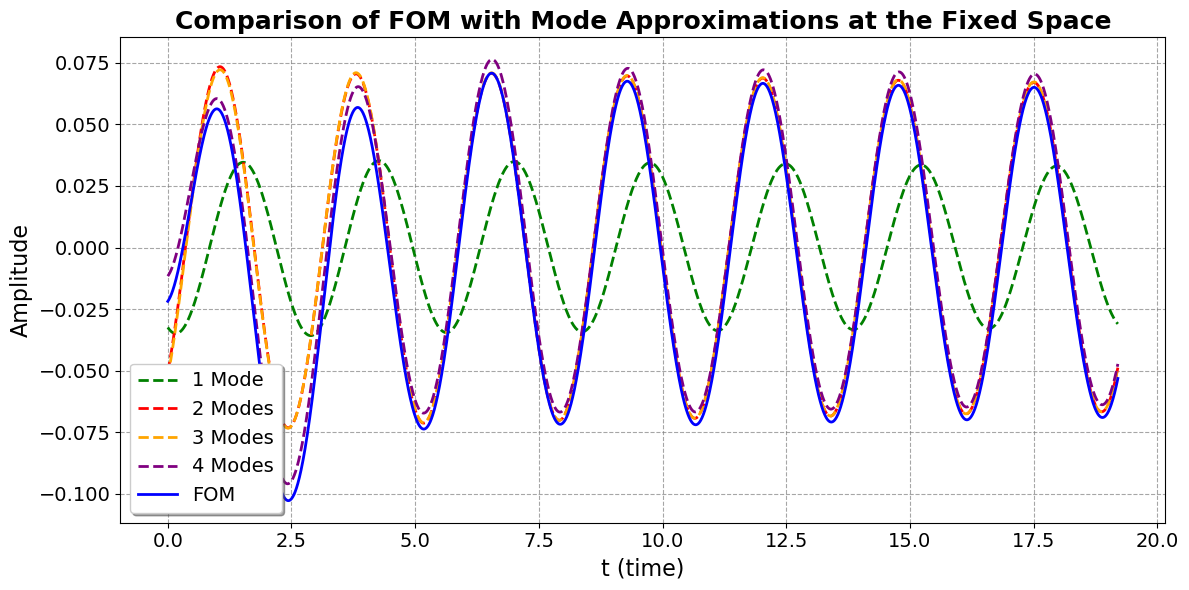

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Example data (replace with your actual data)
# t = np.linspace(0, 10, 100)  # Time vector for demonstration
# T = np.random.rand(100, 50)  # Example data for DNS
# q = np.random.rand(100, 5)  # Example data for modes
# phi_T = np.random.rand(5, 100)  # Example data for phi_T

# Create the plot
plt.figure(figsize=(12, 6))

# Plot 1 Mode
plt.plot(t,np.matmul(q[:, :1], phi_T[:1, :])[:,20], '--', label='1 Mode', color='green', linewidth=2)

# Plot 2 Modes
plt.plot(t,np.matmul(q[:, :2], phi_T[:2, :])[:,20], '--', label='2 Modes', color='red', linewidth=2)

# Plot 3 Modes
plt.plot(t,np.matmul(q[:, :3], phi_T[:3, :])[:,20], '--', label='3 Modes', color='orange', linewidth=2)

# Plot 4 Modes
plt.plot(t,np.matmul(q[:, :4], phi_T[:4, :])[:,20], '--', label='4 Modes', color='purple', linewidth=2)

# Plot DNS data
plt.plot(t,T[:,20], label='FOM', linewidth=2, color='blue', linestyle='-')

# Adding a title and labels
plt.title('Comparison of FOM with Mode Approximations at the Fixed Space', fontsize=18, fontweight='bold')
plt.xlabel('t (time)', fontsize=16)
plt.ylabel('Amplitude', fontsize=16)

# Adding a grid with specific styling
plt.grid(True, linestyle='--', color='gray', alpha=0.7)

# Adding a legend with a shadow and fancy box
plt.legend(fontsize=14, loc='best', shadow=True, fancybox=True)

# Adding a text annotation for clarity (optional)
#plt.text(t[-1], T[-1, 20], 'DNS', color='blue', fontsize=12, ha='right')
#plt.text(t[-1], np.matmul(q[:, :1], phi_T[:1, :])[-1, 20], '1 Mode', color='green', fontsize=12, ha='right')
#plt.text(t[-1], np.matmul(q[:, :2], phi_T[:2, :])[-1, 20], '2 Modes', color='red', fontsize=12, ha='right')
#plt.text(t[-1], np.matmul(q[:, :3], phi_T[:3, :])[-1, 20], '3 Modes', color='orange', fontsize=12, ha='right')
#plt.text(t[-1], np.matmul(q[:, :4], phi_T[:4, :])[-1, 20], '4 Modes', color='purple', fontsize=12, ha='right')

# Adjusting tick parameters for better readability
plt.tick_params(axis='both', which='major', labelsize=14)

# Show plot
plt.tight_layout()

# Save the plot if needed
plt.savefig("Comparison_DNS_2.png", dpi=300)
plt.show()


In [28]:
u_tilde = np.zeros([N,3*NO])
u_hat = np.zeros([N,5*NO])

d_u_tilde = np.zeros([N,3*NO])
d_u_hat = np.zeros([N,5*NO])

In [29]:
phi_KO_new_L = np.zeros([N,NO]) 
phi_RO_new_L = np.zeros([N,NO])
phi_T_new_L = np.zeros([N,NO])



d_phi_KO_new_L = np.zeros([N,NO]) 
d_phi_RO_new_L = np.zeros([N,NO])
d_phi_T_new_L = np.zeros([N,NO])

phi_KO_new_NL = np.zeros([N,NO]) 
phi_RO_new_NL = np.zeros([N,NO])
phi_T_new_NL = np.zeros([N,NO])

In [30]:
for k in range(N):
    phi_KO_new_L[k,:] = (a/2)*(phi_KA[k,:] - phi_RA[k,:]) - c1*d_phi_KO[k,:] - dO*phi_KO[k,:] 
    phi_RO_new_L[k,:] = -(a/3)*(phi_KA[k,:] - phi_RA[k,:]) +  (c1/3)*d_phi_RO[k,:] - dO*phi_RO[k,:] 
    phi_T_new_L[k,:] = c1*eta*(phi_KO[k,:] + phi_RO[k,:]) - b*phi_T[k,:] 
   
    d_phi_KO_new_L[k,:] = (a/2)*(d_phi_KA[k,:] - d_phi_RA[k,:]) - c1*dd_phi_KO[k,:] - dO*dd_phi_KO[k,:]
    d_phi_RO_new_L[k,:] = -(a/3)*(d_phi_KA[k,:] - d_phi_RA[k,:]) + (c1/3)*dd_phi_RO[k,:] - dO*dd_phi_RO[k,:]    
    d_phi_T_new_L[k,:] = c1*eta*(d_phi_KO[k,:] + d_phi_RO[k,:]) - b*d_phi_T[k,:] 

In [31]:
for k in range(N):
    phi_T_new_NL[k,:] = - (d_phi_KO[k,:]*phi_T[k,:] 
                            + d_phi_T[k,:]*phi_KO[k,:]  
                            - d_phi_RO[k,:]*phi_T[k,:] 
                            - d_phi_T[k,:]*phi_RO[k,:])

In [32]:
for k in range(N):
    u_hat[k,:] = np.block([phi_KA[k,:], phi_RA[k,:], phi_KO[k,:], phi_RO[k,:], phi_T[k,:]]) 
    u_tilde[k,:] =  np.block([phi_KO[k,:], phi_RO[k,:], phi_T[k,:]]) 
    
    d_u_hat[k,:] = np.block([d_phi_KA[k,:], d_phi_RA[k,:], d_phi_KO[k,:], d_phi_RO[k,:], d_phi_T[k,:]]) 
    d_u_tilde[k,:] =  np.block([d_phi_KO[k,:], d_phi_RO[k,:], d_phi_T[k,:]]) 

In [33]:
u_tilde_2 = np.zeros([N,3*NO])
u_tilde_NL = np.zeros([N,3*NO])
d_u_tilde_2 = np.zeros([N,3*NO])
d_u_tilde_NL = np.zeros([N,3*NO])

for k in range(N):
    u_tilde_2[k,:] =  np.block([phi_KO_new_L[k,:], phi_RO_new_L[k,:], phi_T_new_L[k,:]])
    d_u_tilde_2[k,:] =  np.block([d_phi_KO_new_L[k,:], d_phi_RO_new_L[k,:], d_phi_T_new_L[k,:]])
    u_tilde_NL[k,:] =  np.block([phi_KO_new_NL[k,:], phi_RO_new_NL[k,:], phi_T_new_NL[k,:]])

In [34]:
A = np.zeros([N,N])


In [35]:
np.shape(u_tilde_2)

(4, 504)

In [36]:
for i in range(0,N):
    for k in range(0,N):
        A[i,k] = np.inner(u_tilde_2[k,:], u_tilde[i,:]) + eps*np.inner(d_u_tilde_2[k,:], d_u_tilde[i,:])

In [37]:
A

array([[-0.00732158,  3.65512502,  1.03718356,  0.54465211],
       [-1.43138872,  0.01599287,  0.24808468, -0.64356234],
       [-0.02085785, -0.0072678 , -0.42960164,  0.61641041],
       [-0.00569762, -0.00449807, -0.91014509, -0.51939244]])

In [38]:
eig_A , y_A = np.linalg.eig(A)
print(eig_A)

[ 0.00295204+2.29046347j  0.00295204-2.29046347j -0.47311344+0.75291229j
 -0.47311344-0.75291229j]


In [39]:
B = np.zeros([N,N,N])

In [40]:
for i in range(0,N):
    for k in range(0,N):
        for j in range(0,N):
            B[i,k,j]= -np.inner( np.block([phi_KO_new_NL[k,:], phi_RO_new_NL[k,:], d_phi_KO[k,:]*phi_T[j,:]]) 
                            + np.block([phi_KO_new_NL[k,:], phi_RO_new_NL[k,:],d_phi_T[k,:]*phi_KO[j,:]])  
                            - np.block([phi_KO_new_NL[k,:], phi_RO_new_NL[k,:],d_phi_RO[k,:]*phi_T[j,:]]) 
                            - np.block([phi_KO_new_NL[k,:], phi_RO_new_NL[k,:],d_phi_T[k,:]*phi_RO[j,:]]), u_tilde[i,:]) \
            
            +eps*np.inner(np.block([phi_KO_new_NL[k,:], phi_RO_new_NL[k,:], dd_phi_KO[k,:]*phi_T[j,:]]) 
                            + np.block([phi_KO_new_NL[k,:], phi_RO_new_NL[k,:],d_phi_KO[k,:]*d_phi_KO[j,:]])  
                            - np.block([phi_KO_new_NL[k,:], phi_RO_new_NL[k,:],dd_phi_KO[k,:]*phi_T[j,:]]) 
                            - np.block([phi_KO_new_NL[k,:], phi_RO_new_NL[k,:],d_phi_KO[k,:]*d_phi_RO[j,:]]), d_u_tilde[i,:]) 

In [41]:
B[0,:,:]

array([[ 0.00276132,  0.00806554,  0.01079804,  0.02402945],
       [ 0.00978386, -0.00386827, -0.00721726, -0.01838066],
       [-0.00734539,  0.00644515,  0.0002599 ,  0.00711109],
       [-0.04165966,  0.01787977,  0.00023983,  0.01691068]])

In [42]:
B[1,:,:]

array([[-0.01519521,  0.02045543,  0.00793702,  0.00564426],
       [-0.01142614,  0.01630207, -0.00759445, -0.022152  ],
       [-0.07264245,  0.00887803,  0.00140823,  0.02531242],
       [-0.01450022,  0.02749727, -0.01226335, -0.00334675]])

In [43]:
B[2,:,:]

array([[ 0.00793651,  0.02713307,  0.01208482,  0.05144067],
       [ 0.05331769, -0.010868  , -0.00690125, -0.07542641],
       [-0.00561782,  0.03384799, -0.01942488,  0.03678055],
       [-0.13638135,  0.04378817,  0.00074559,  0.07783737]])

In [44]:
B[3,:,:]

array([[ 0.04439763,  0.01058378,  0.04477799,  0.05003795],
       [-0.00599635, -0.02722043, -0.04308332, -0.07064836],
       [ 0.11383153,  0.05222531, -0.01207118,  0.04309056],
       [-0.01337853,  0.06016976, -0.03044973,  0.0829298 ]])

In [45]:
mu = 0.04

In [46]:
def model_Galerkin_4(t,a):
    a1, a2, a3 , a4  = a
    d_a1 =  A[0,0]*a1 + A[0,1]*a2 + A[0,2]*a3 + A[0,3]*a4  + \
     (mu)*(B[0,0,0]*a1*a1 +  B[0,0,1]*a1*a2 + B[0,0,2]*a1*a3 + B[0,0,3]*a1*a4  + \
     B[0,1,0]*a2*a1 +  B[0,1,1]*a2*a2 + B[0,1,2]*a2*a3 + B[0,1,3]*a2*a4 + \
     B[0,2,0]*a3*a1 +  B[0,2,1]*a3*a2 + B[0,2,2]*a3*a3 + B[0,2,3]*a3*a4 +   \
     B[0,3,0]*a4*a1 +  B[0,3,1]*a4*a2 + B[0,3,2]*a4*a3 + B[0,3,3]*a4*a4       ) 
    
    d_a2 = A[1,0]*a1 + A[1,1]*a2 + A[1,2]*a3 + A[1,3]*a4  + \
     (mu)*(B[1,0,0]*a1*a1 +  B[1,0,1]*a1*a2 + B[1,0,2]*a1*a3 + B[1,0,3]*a1*a4  + \
     B[1,1,0]*a2*a1 +  B[1,1,1]*a2*a2 + B[1,1,2]*a2*a3 + B[1,1,3]*a2*a4 +  \
     B[1,2,0]*a3*a1 +  B[1,2,1]*a3*a2 + B[1,2,2]*a3*a3 + B[1,2,3]*a3*a4 +    \
     B[1,3,0]*a4*a1 +  B[1,3,1]*a4*a2 + B[1,3,2]*a4*a3 + B[1,3,3]*a4*a4   ) 
    
    d_a3 = A[2,0]*a1 + A[2,1]*a2 + A[2,2]*a3 + A[2,3]*a4  + \
     (mu)*(B[2,0,0]*a1*a1 +  B[2,0,1]*a1*a2 + B[2,0,2]*a1*a3 + B[2,0,3]*a1*a4  + \
     B[2,1,0]*a2*a1 +  B[2,1,1]*a2*a2 + B[2,1,2]*a2*a3 + B[2,1,3]*a2*a4 + \
     B[2,2,0]*a3*a1 +  B[2,2,1]*a3*a2 + B[2,2,2]*a3*a3 + B[2,2,3]*a3*a4  +  \
     B[2,3,0]*a4*a1 +  B[2,3,1]*a4*a2 + B[2,3,2]*a4*a3 + B[2,3,3]*a4*a4     ) 
    
    d_a4 = A[3,0]*a1 + A[3,1]*a2 + A[3,2]*a3 + A[3,3]*a4 + \
     (mu)*(B[3,0,0]*a1*a1 +  B[3,0,1]*a1*a2 + B[3,0,2]*a1*a3 + B[3,0,3]*a1*a4 + \
     B[3,1,0]*a2*a1 +  B[3,1,1]*a2*a2 + B[3,1,2]*a2*a3 + B[3,1,3]*a2*a4  + \
     B[3,2,0]*a3*a1 +  B[3,2,1]*a3*a2 + B[3,2,2]*a3*a3 + B[3,2,3]*a3*a4  +   \
     B[3,3,0]*a4*a1 +  B[3,3,1]*a4*a2 + B[3,3,2]*a4*a3 + B[3,3,3]*a4*a4   ) 

    return [d_a1, d_a2, d_a3, d_a4]

In [47]:
Initial = np.zeros([3*NO])
#Psi = np.zeros([3*NO,N])

In [48]:
Initial = np.block([KO[0,:], RO[0,:], T[0,:]])

In [49]:
y0 = np.zeros(N)
for k in range(N):
    y0[k] = np.inner(Psi[:,k],Initial[:])

In [50]:
#y0 = y0/2

In [51]:
y0

array([-5.57069707, -1.08029643, -0.95155949, -0.60850223])

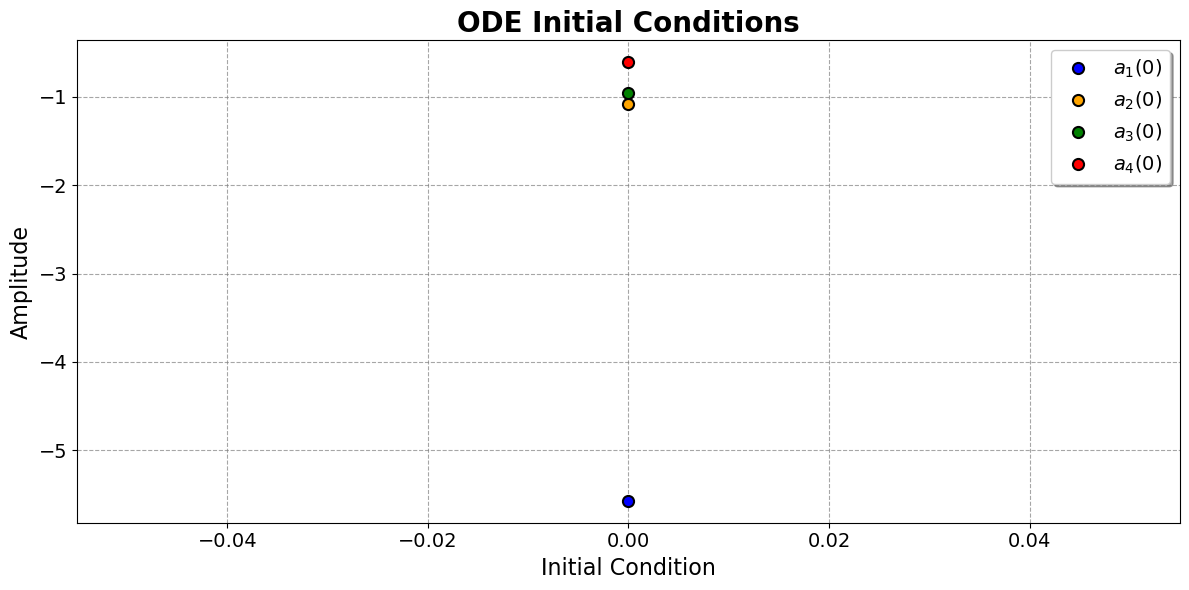

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# Example data (replace with your actual data)
# y0 = np.random.rand(6, 100)  # Example data for demonstration, replace with your actual y0

# Create the plot
plt.figure(figsize=(12, 6))

# Plot each series with different colors and markers
plt.plot(y0[0], 'o', label=r'$a_1(0)$', color='blue', markersize=8, markeredgewidth=1.5, markeredgecolor='black')
plt.plot(y0[1], 'o', label=r'$a_2(0)$', color='orange', markersize=8, markeredgewidth=1.5, markeredgecolor='black')
plt.plot(y0[2], 'o', label=r'$a_3(0)$', color='green', markersize=8, markeredgewidth=1.5, markeredgecolor='black')
plt.plot(y0[3], 'o', label=r'$a_4(0)$', color='red', markersize=8, markeredgewidth=1.5, markeredgecolor='black')
# Uncomment the following lines if you want to plot more series
# plt.plot(y0[4], 'o', label=r'$a_5(0)$', color='purple', markersize=8, markeredgewidth=1.5, markeredgecolor='black')
# plt.plot(y0[5], 'o', label=r'$a_6(0)$', color='brown', markersize=8, markeredgewidth=1.5, markeredgecolor='black')

# Adding a title and labels
plt.title('ODE Initial Conditions', fontsize=20, fontweight='bold')
plt.xlabel('Initial Condition', fontsize=16)
plt.ylabel('Amplitude', fontsize=16)

# Adding a grid with specific styling
plt.grid(True, linestyle='--', color='gray', alpha=0.7)

# Adding a legend with a shadow and fancy box
plt.legend(fontsize=14, loc='best', shadow=True, fancybox=True)

# Adjusting tick parameters for better readability
plt.tick_params(axis='both', which='major', labelsize=14)

# Show plot
plt.tight_layout()
plt.savefig("ODE_Initial_Conditions.png", dpi=300)
plt.show()

# Save the plot if needed


In [53]:
I_KO_R = np.matmul(y0,phi_KO)
I_RO_R = np.matmul(y0,phi_RO)
I_T_R = np.matmul(y0,phi_T)

In [54]:
I_R = np.block([I_KO_R , I_RO_R , I_T_R ])

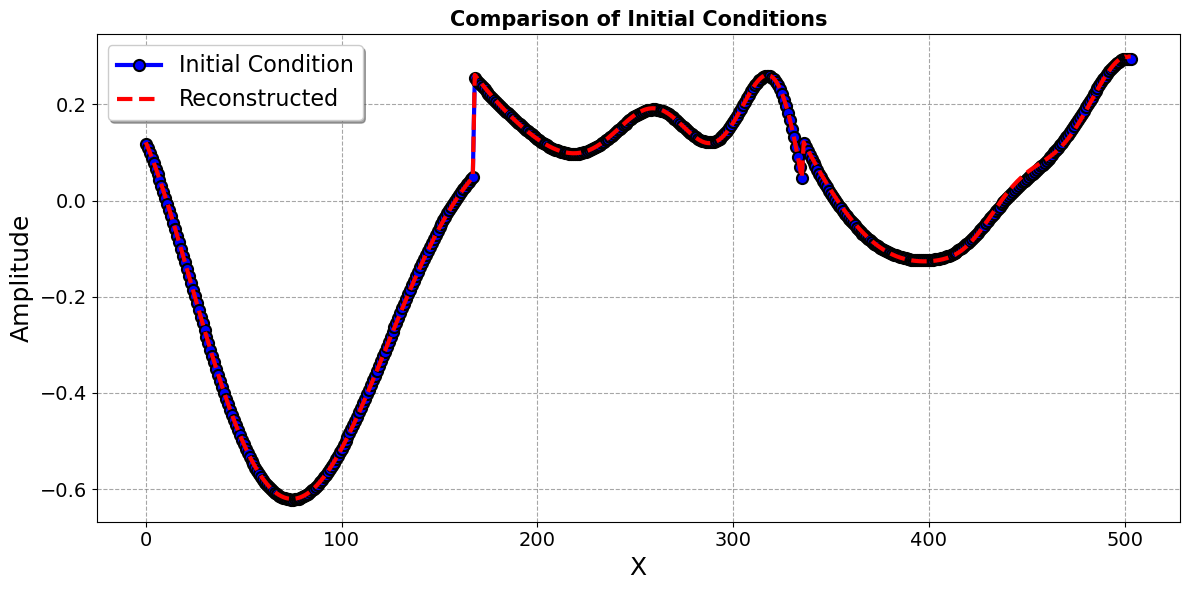

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Example data (replace with your actual data)
# Initial = np.sin(np.linspace(0, 10, 100))  # Example data for demonstration
# I_R = np.sin(np.linspace(0, 10, 100)) + 0.1  # Example data for demonstration

# Create the plot
plt.figure(figsize=(12,6))

# Plot the Initial data
plt.plot(Initial, 
         label='Initial Condition', 
         color='blue', 
         linewidth=3, 
         linestyle='-', 
         marker='o', 
         markersize=8, 
         markeredgewidth=1.5, 
         markeredgecolor='black')

# Plot the I_R data
plt.plot(I_R, 
         label='Reconstructed', 
         color='red', 
         linewidth=3, 
         linestyle='--', 
         markersize=8, 
         markeredgewidth=1.5, 
         markeredgecolor='black')

# Adding a title and labels
plt.title('Comparison of Initial Conditions', fontsize=15, fontweight='bold')
plt.xlabel('X', fontsize=18)
plt.ylabel('Amplitude', fontsize=18)

# Adding a grid with specific styling
plt.grid(True, linestyle='--', color='gray', alpha=0.7)

# Adding a legend with a shadow and fancy box
plt.legend(fontsize=16, loc='best', shadow=True, fancybox=True)

# Adjusting tick parameters for better readability
plt.tick_params(axis='both', which='major', labelsize=14)

# Show plot
plt.tight_layout()
plt.savefig("Comparison_Initial.png", dpi=300)

plt.show()

# Save the plot if needed


In [55]:
t_f = 2*9.6

In [56]:
t

array([0.00000000e+00, 6.66898229e-03, 1.33379646e-02, ...,
       1.91866620e+01, 1.91933310e+01, 1.92000000e+01])

In [57]:
from scipy.integrate import solve_ivp
#solutions_S = solve_ivp(model_SINDy, [0,t_f] ,y0, t_eval = t,method='RK23')
solutions_G = solve_ivp(model_Galerkin_4, [0,t_f] ,y0, t_eval = t, method='RK23')

In [58]:
t.shape

(2880,)

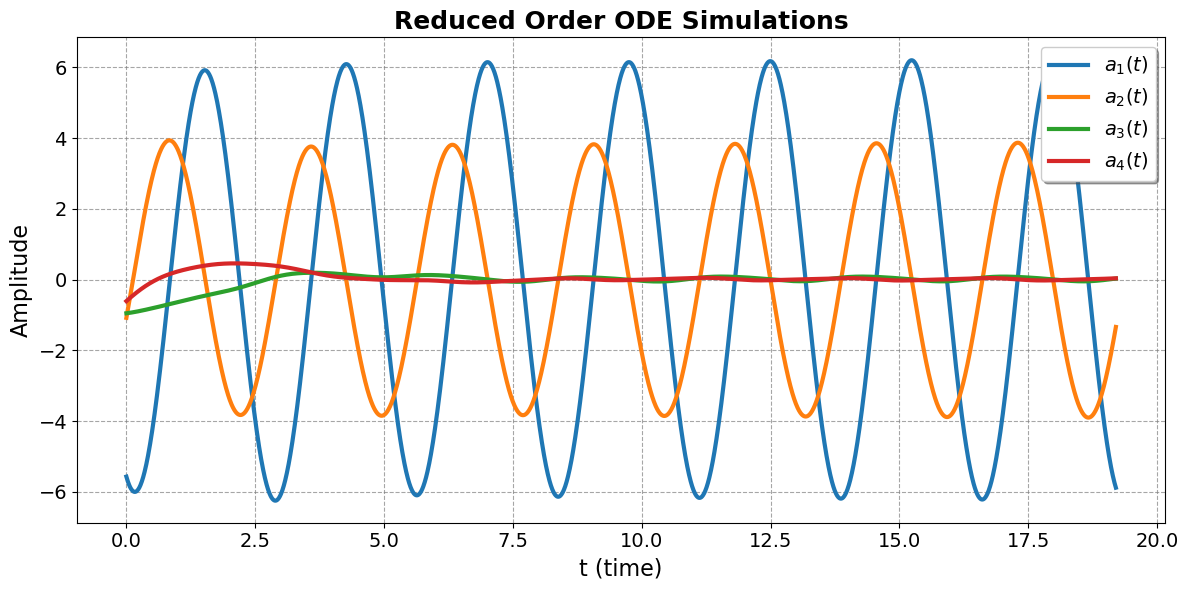

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# Example data
# N = 5  # Number of modes for demonstration
# q = np.random.rand(100, N)  # Example data for demonstration

plt.figure(figsize=(12, 6))

# Loop to plot each mode with different styles
for k in range(0,N):
    plt.plot(t,solutions_G.y[k, :], label=f'$a_{k+1}(t)$', linewidth=3)

# Adding title and labels
plt.title('Reduced Order ODE Simulations', fontsize=18, fontweight='bold')
plt.xlabel('t (time)', fontsize=16)
plt.ylabel('Amplitude', fontsize=16)

# Adding a grid with specific styling
plt.grid(True, linestyle='--', color='gray', alpha=0.7)

# Adding a legend with a shadow and fancy box
plt.legend(fontsize=14, loc='upper right', shadow=True, fancybox=True)

# Adding annotations for better clarity
#for k in range(0, N):
#    plt.text(len(q) - 1, q[-1, k], f'Mode {k+1}', color=plt.gca().get_lines()[k].get_color(), fontsize=10, ha='left')

# Adjusting tick parameters for better readability
plt.tick_params(axis='both', which='major', labelsize=14)

# Show plot
plt.tight_layout()
plt.savefig("Galerkin_a_Plot.png", dpi=300)

plt.show()

# Save the plot if needed


In [60]:
KA_G_R = np.matmul(solutions_G.y.T,phi_KA)
RA_G_R = np.matmul(solutions_G.y.T,phi_RA)
KO_G_R = np.matmul(solutions_G.y.T,phi_KO)
RO_G_R = np.matmul(solutions_G.y.T,phi_RO)
T_G_R = np.matmul(solutions_G.y.T,phi_T)
#T_G_R_L = np.matmul(solutions2.y.T,phi_T)

In [61]:
print(np.sqrt(np.sum((KA-KA_G_R)**2)/(NO*t_N)))
print(np.sqrt(np.sum((RA-RA_G_R)**2)/(NO*t_N)))
print(np.sqrt(np.sum((KO-KO_G_R)**2)/(NO*t_N)))
print(np.sqrt(np.sum((RO-RO_G_R)**2)/(NO*t_N)))
print(np.sqrt(np.sum((T-T_G_R)**2)/(NO*t_N)))

0.03683485850886784
0.021160079225816714
0.022244338163126272
0.009709996544963307
0.008382627273537651


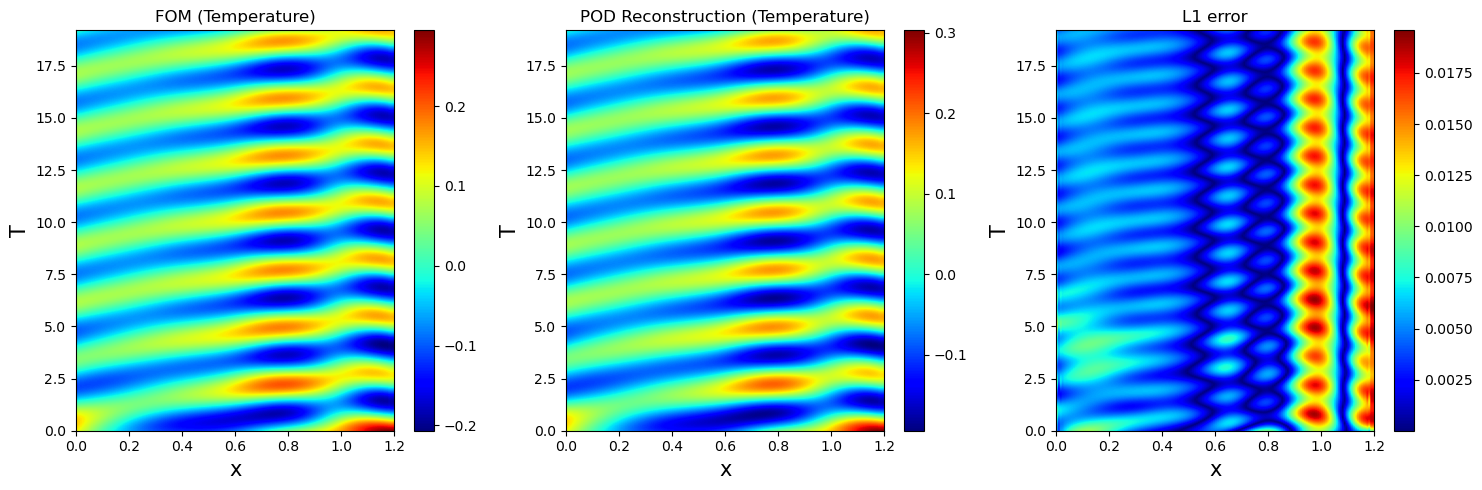

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming xO and t are defined, and T_WCE and T_MC_mean_300 are the 2D data arrays.
# You may need to adjust the indices or slicing based on your actual data shapes.

# Set up a figure with three subplots
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# First subplot: T mean (WCE)
c1 = ax[0].imshow(T[:, :], aspect='auto', extent=[xO.min(), xO.max(), t.max(), t.min()], cmap='jet')
ax[0].set_xlabel('x', fontsize=15)
ax[0].set_ylabel('T', fontsize=15)
ax[0].set_title('FOM (Temperature)')
ax[0].invert_yaxis()  # Invert y-axis to have time go from bottom to top
fig.colorbar(c1, ax=ax[0], orientation='vertical')

# Second subplot: T mean (MC)
c2 = ax[1].imshow(T_R[:, :], aspect='auto', extent=[xO.min(), xO.max(), t.max(), t.min()], cmap='jet')
ax[1].set_xlabel('x', fontsize=15)
ax[1].set_ylabel('T', fontsize=15)
ax[1].set_title('POD Reconstruction (Temperature)')
ax[1].invert_yaxis()  # Invert y-axis to have time go from bottom to top
fig.colorbar(c2, ax=ax[1], orientation='vertical')

# Third subplot: L1 error
c3 = ax[2].imshow(np.abs(T[:, :] - T_R[:, :]), aspect='auto', extent=[xO.min(), xO.max(), t.max(), t.min()], cmap='jet')
ax[2].set_xlabel('x', fontsize=15)
ax[2].set_ylabel('T', fontsize=15)
ax[2].set_title('L1 error')
ax[2].invert_yaxis()  # Invert y-axis to have time go from bottom to top
fig.colorbar(c3, ax=ax[2], orientation='vertical')

# Adjust layout
plt.tight_layout()
# Save the figure if needed
#plt.savefig("POD_Reconstruction_2D.png")

plt.show()


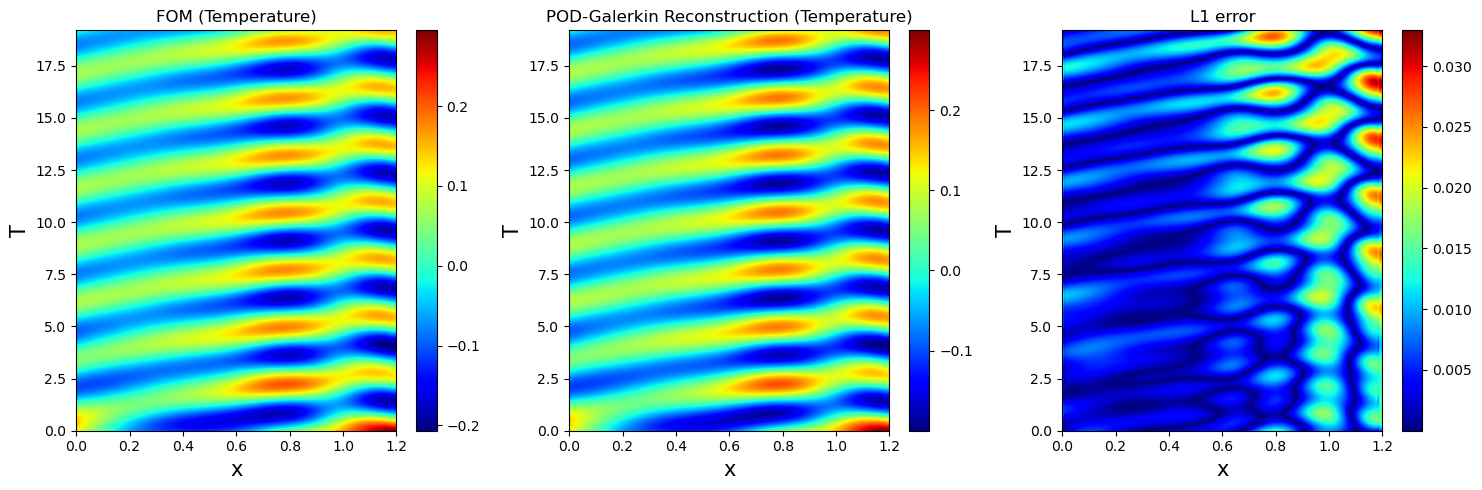

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming xO and t are defined, and T_WCE and T_MC_mean_300 are the 2D data arrays.
# You may need to adjust the indices or slicing based on your actual data shapes.

# Set up a figure with three subplots
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# First subplot: T mean (WCE)
c1 = ax[0].imshow(T[:, :], aspect='auto', extent=[xO.min(), xO.max(), t.max(), t.min()], cmap='jet')
ax[0].set_xlabel('x', fontsize=15)
ax[0].set_ylabel('T', fontsize=15)
ax[0].set_title('FOM (Temperature)')
ax[0].invert_yaxis()  # Invert y-axis to have time go from bottom to top
fig.colorbar(c1, ax=ax[0], orientation='vertical')

# Second subplot: T mean (MC)
c2 = ax[1].imshow(T_G_R[:, :], aspect='auto', extent=[xO.min(), xO.max(), t.max(), t.min()], cmap='jet')
ax[1].set_xlabel('x', fontsize=15)
ax[1].set_ylabel('T', fontsize=15)
ax[1].set_title('POD-Galerkin Reconstruction (Temperature)')
ax[1].invert_yaxis()  # Invert y-axis to have time go from bottom to top
fig.colorbar(c2, ax=ax[1], orientation='vertical')

# Third subplot: L1 error
c3 = ax[2].imshow(np.abs(T[:, :] - T_G_R[:, :]), aspect='auto', extent=[xO.min(), xO.max(), t.max(), t.min()], cmap='jet')
ax[2].set_xlabel('x', fontsize=15)
ax[2].set_ylabel('T', fontsize=15)
ax[2].set_title('L1 error')
ax[2].invert_yaxis()  # Invert y-axis to have time go from bottom to top
fig.colorbar(c3, ax=ax[2], orientation='vertical')

# Adjust layout
plt.tight_layout()
# Save the figure if needed
plt.savefig("POD_Galerkin_Reconstruction_2D.png")

plt.show()


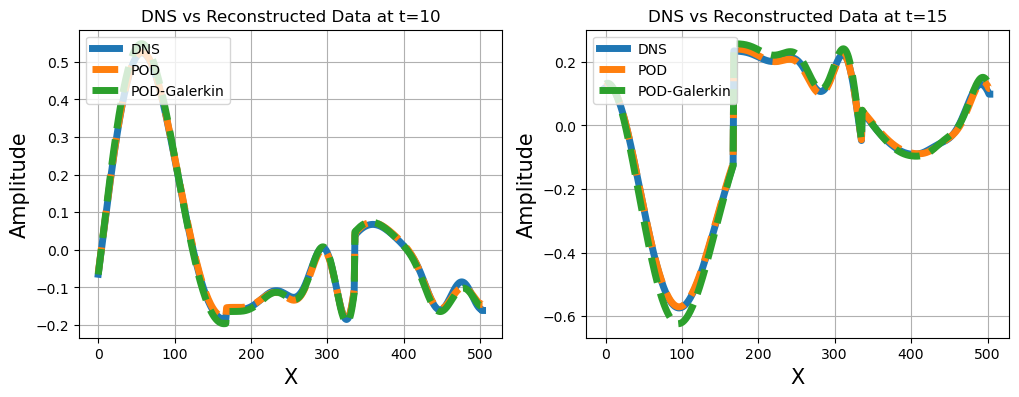

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# Your data arrays (assuming these are defined)
# KO, RO, T, KO_R, RO_R, T_R, KO_G_R, RO_G_R, T_G_R = ...

# Create figure and subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Plot data for t=10
axs[0].plot(np.block([KO[1400, :], RO[1400, :], T[1400, :]]), linewidth=5)
axs[0].plot(np.block([KO_R[1400, :], RO_R[1400, :], T_R[1400, :]]), '--', linewidth=5)
axs[0].plot(np.block([KO_G_R[1400, :], RO_G_R[1400, :], T_G_R[1400, :]]), '--', linewidth=5)
axs[0].legend(['DNS', 'POD', 'POD-Galerkin'], loc='upper left')
axs[0].set_title('DNS vs Reconstructed Data at t=10')
axs[0].set_xlabel('X', fontsize=15)
axs[0].set_ylabel('Amplitude', fontsize=15)

axs[0].grid(True)

# Plot data for t=15
axs[1].plot(np.block([KO[2100, :], RO[2100, :], T[2100, :]]), linewidth=5)
axs[1].plot(np.block([KO_R[2100, :], RO_R[2100, :], T_R[2100, :]]), '--', linewidth=5)
axs[1].plot(np.block([KO_G_R[2100, :], RO_G_R[2100, :], T_G_R[2100, :]]), '--', linewidth=5)
axs[1].legend(['DNS', 'POD', 'POD-Galerkin'], loc='upper left')
axs[1].set_title('DNS vs Reconstructed Data at t=15')
axs[1].set_xlabel('X', fontsize=15)
axs[1].set_ylabel('Amplitude', fontsize=15)

axs[1].grid(True)

# Adding a main title to the entire figure
#fig.suptitle('Snapshots of DNS vs Reconstructed Data', fontsize=16)

# Save the combined plot
plt.savefig("POD-Galerkin_Reconstruction_combined.png")

# Display the plot
plt.show()


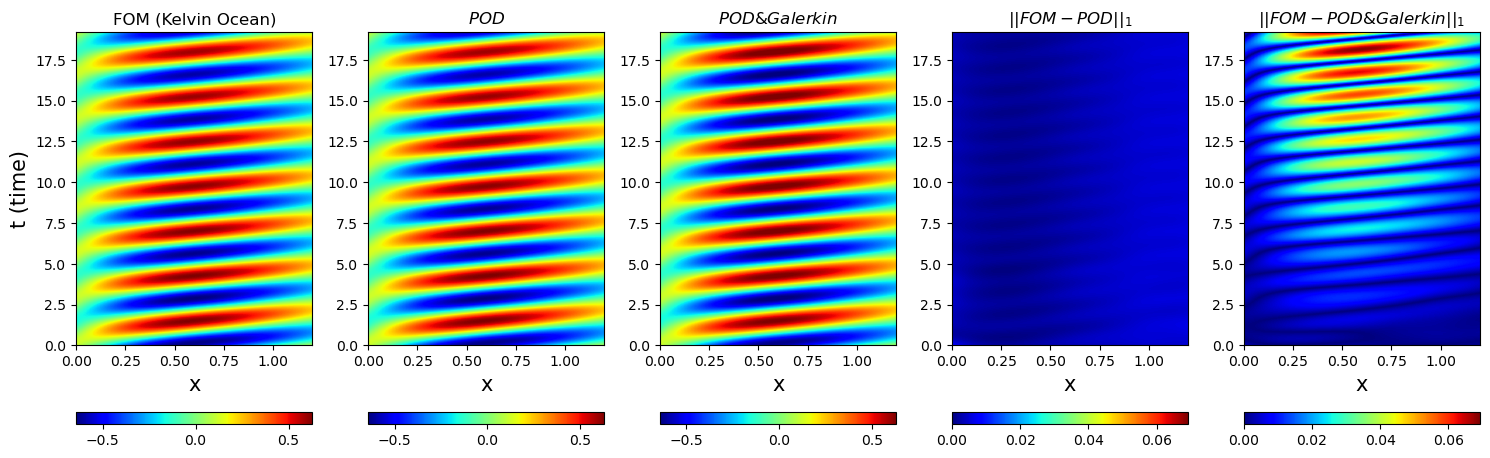

In [65]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 5, figsize=(15, 5))

# First subplot: T mean (WCE)
c1 = ax[0].imshow(KO[:, :], aspect='auto', extent=[xO.min(), xO.max(), t.max(), t.min()], vmin=KO.min(), vmax=KO.max(), cmap='jet')
ax[0].set_xlabel('x', fontsize=15)
ax[0].set_ylabel('t (time)', fontsize=15)
ax[0].set_title('FOM (Kelvin Ocean)')
ax[0].invert_yaxis()  # Invert y-axis to have time go from bottom to top
fig.colorbar(c1, ax=ax[0], orientation='horizontal')

# Second subplot: T mean (MC)
c2 = ax[1].imshow(KO_R[:, :], aspect='auto', extent=[xO.min(), xO.max(), t.max(), t.min()], vmin=KO.min(), vmax=KO.max(),cmap='jet')
ax[1].set_xlabel('x', fontsize=15)
#ax[1].set_ylabel('T', fontsize=15)
ax[1].set_title('$POD$')
ax[1].invert_yaxis()  # Invert y-axis to have time go from bottom to top
fig.colorbar(c2, ax=ax[1], orientation='horizontal')

# Third subplot: L1 error
c3 = ax[2].imshow(KO_G_R[:,:], aspect='auto', extent=[xO.min(), xO.max(), t.max(), t.min()],vmin=KO.min(), vmax=KO.max(), cmap='jet')
ax[2].set_xlabel('x', fontsize=15)
#ax[2].set_ylabel('T', fontsize=15)
ax[2].set_title('$POD&Galerkin$')
ax[2].invert_yaxis()  # Invert y-axis to have time go from bottom to top
fig.colorbar(c3, ax=ax[2], orientation='horizontal')


c4 = ax[3].imshow(np.abs(KO[:, :] - KO_R[:, :]), aspect='auto', extent=[xO.min(), xO.max(), t.max(), t.min()], vmin=0, vmax=np.abs(KO[:, :] - KO_G_R[:, :]).max(),cmap='jet')
ax[3].set_xlabel('x', fontsize=15)
#ax[3].set_ylabel('T', fontsize=15)
ax[3].set_title('$||FOM-POD||_1$')
ax[3].invert_yaxis()  # Invert y-axis to have time go from bottom to top
fig.colorbar(c4, ax=ax[3], orientation='horizontal')



c5 = ax[4].imshow(np.abs(KO[:, :] - KO_G_R[:, :]), aspect='auto', extent=[xO.min(), xO.max(), t.max(), t.min()],vmin=0, vmax=np.abs(KO[:, :] - KO_G_R[:, :]).max(), cmap='jet')
ax[4].set_xlabel('x', fontsize=15)
#ax[4].set_ylabel('T', fontsize=15)
ax[4].set_title('$||FOM-POD&Galerkin||_1$')
ax[4].invert_yaxis()  # Invert y-axis to have time go from bottom to top
fig.colorbar(c5, ax=ax[4], orientation='horizontal')



# Adjust layout
plt.tight_layout()
# Save the figure if needed
plt.savefig("POD_G_Kelvin_Reconstruction_2D.png")

plt.show()


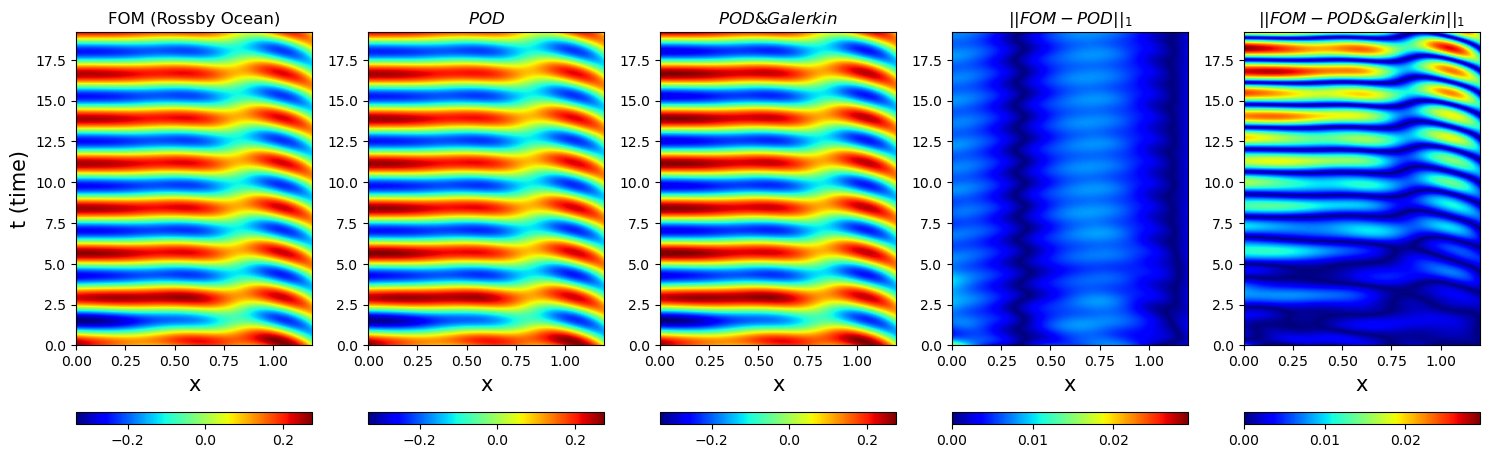

In [66]:
import matplotlib.pyplot as plt
import numpy as np



fig, ax = plt.subplots(1, 5, figsize=(15, 5))

# First subplot: T mean (WCE)
c1 = ax[0].imshow(RO[:, :], aspect='auto', extent=[xO.min(), xO.max(), t.max(), t.min()], vmin=RO.min(), vmax=RO.max(), cmap='jet')
ax[0].set_xlabel('x', fontsize=15)
ax[0].set_ylabel('t (time)', fontsize=15)
ax[0].set_title('FOM (Rossby Ocean)')
ax[0].invert_yaxis()  # Invert y-axis to have time go from bottom to top
fig.colorbar(c1, ax=ax[0], orientation='horizontal')

# Second subplot: T mean (MC)
c2 = ax[1].imshow(RO_R[:, :], aspect='auto', extent=[xO.min(), xO.max(), t.max(), t.min()], vmin=RO.min(), vmax=RO.max(),cmap='jet')
ax[1].set_xlabel('x', fontsize=15)
#ax[1].set_ylabel('T', fontsize=15)
ax[1].set_title('$POD$')
ax[1].invert_yaxis()  # Invert y-axis to have time go from bottom to top
fig.colorbar(c2, ax=ax[1], orientation='horizontal')

# Third subplot: L1 error
c3 = ax[2].imshow(RO_G_R[:,:], aspect='auto', extent=[xO.min(), xO.max(), t.max(), t.min()],vmin=RO.min(), vmax=RO.max(), cmap='jet')
ax[2].set_xlabel('x', fontsize=15)
#ax[2].set_ylabel('T', fontsize=15)
ax[2].set_title('$POD&Galerkin$')
ax[2].invert_yaxis()  # Invert y-axis to have time go from bottom to top
fig.colorbar(c3, ax=ax[2], orientation='horizontal')


c4 = ax[3].imshow(np.abs(RO[:, :] - RO_R[:, :]), aspect='auto', extent=[xO.min(), xO.max(), t.max(), t.min()], vmin=0, vmax=np.abs(RO[:, :] - RO_G_R[:, :]).max(),cmap='jet')
ax[3].set_xlabel('x', fontsize=15)
#ax[3].set_ylabel('T', fontsize=15)
ax[3].set_title('$||FOM-POD||_1$')
ax[3].invert_yaxis()  # Invert y-axis to have time go from bottom to top
fig.colorbar(c4, ax=ax[3], orientation='horizontal')



c5 = ax[4].imshow(np.abs(RO[:, :] - RO_G_R[:, :]), aspect='auto', extent=[xO.min(), xO.max(), t.max(), t.min()],vmin=0, vmax=np.abs(RO[:, :] - RO_G_R[:, :]).max(), cmap='jet')
ax[4].set_xlabel('x', fontsize=15)
#ax[4].set_ylabel('T', fontsize=15)
ax[4].set_title('$||FOM-POD&Galerkin||_1$')
ax[4].invert_yaxis()  # Invert y-axis to have time go from bottom to top
fig.colorbar(c5, ax=ax[4], orientation='horizontal')

# Adjust layout
plt.tight_layout()
# Save the figure if needed
plt.savefig("POD_G_Rossby_Reconstruction_2D.png")

plt.show()


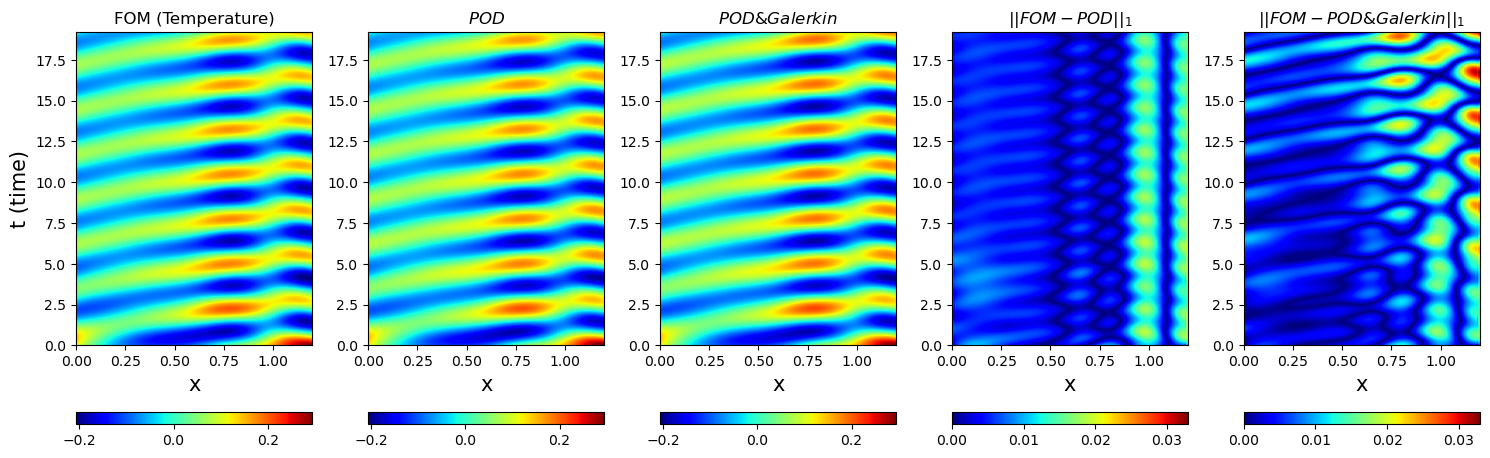

In [67]:
import matplotlib.pyplot as plt
import numpy as np


fig, ax = plt.subplots(1, 5, figsize=(15, 5))

# First subplot: T mean (WCE)
c1 = ax[0].imshow(T[:, :], aspect='auto', extent=[xO.min(), xO.max(), t.max(), t.min()], vmin=T.min(), vmax=T.max(), cmap='jet')
ax[0].set_xlabel('x', fontsize=15)
ax[0].set_ylabel('t (time)', fontsize=15)
ax[0].set_title('FOM (Temperature)')
ax[0].invert_yaxis()  # Invert y-axis to have time go from bottom to top
fig.colorbar(c1, ax=ax[0], orientation='horizontal')

# Second subplot: T mean (MC)
c2 = ax[1].imshow(T_R[:, :], aspect='auto', extent=[xO.min(), xO.max(), t.max(), t.min()], vmin=T.min(), vmax=T.max(),cmap='jet')
ax[1].set_xlabel('x', fontsize=15)
#ax[1].set_ylabel('T', fontsize=15)
ax[1].set_title('$POD$')
ax[1].invert_yaxis()  # Invert y-axis to have time go from bottom to top
fig.colorbar(c2, ax=ax[1], orientation='horizontal')

# Third subplot: L1 error
c3 = ax[2].imshow(T_G_R[:,:], aspect='auto', extent=[xO.min(), xO.max(), t.max(), t.min()],vmin=T.min(), vmax=T.max(), cmap='jet')
ax[2].set_xlabel('x', fontsize=15)
#ax[2].set_ylabel('T', fontsize=15)
ax[2].set_title('$POD&Galerkin$')
ax[2].invert_yaxis()  # Invert y-axis to have time go from bottom to top
fig.colorbar(c3, ax=ax[2], orientation='horizontal')


c4 = ax[3].imshow(np.abs(T[:, :] - T_R[:, :]), aspect='auto', extent=[xO.min(), xO.max(), t.max(), t.min()], vmin=0, vmax=np.abs(T[:, :] - T_G_R[:, :]).max(),cmap='jet')
ax[3].set_xlabel('x', fontsize=15)
#ax[3].set_ylabel('T', fontsize=15)
ax[3].set_title('$||FOM-POD||_1$')
ax[3].invert_yaxis()  # Invert y-axis to have time go from bottom to top
fig.colorbar(c4, ax=ax[3], orientation='horizontal')



c5 = ax[4].imshow(np.abs(T[:, :] - T_G_R[:, :]), aspect='auto', extent=[xO.min(), xO.max(), t.max(), t.min()],vmin=0, vmax=np.abs(T[:, :] - T_G_R[:, :]).max(), cmap='jet')
ax[4].set_xlabel('x', fontsize=15)
#ax[4].set_ylabel('T', fontsize=15)
ax[4].set_title('$||FOM-POD&Galerkin||_1$')
ax[4].invert_yaxis()  # Invert y-axis to have time go from bottom to top
fig.colorbar(c5, ax=ax[4], orientation='horizontal')

# Adjust layout
plt.tight_layout()
# Save the figure if needed
plt.savefig("POD_G_Temp_Reconstruction_2D.png")

plt.show()


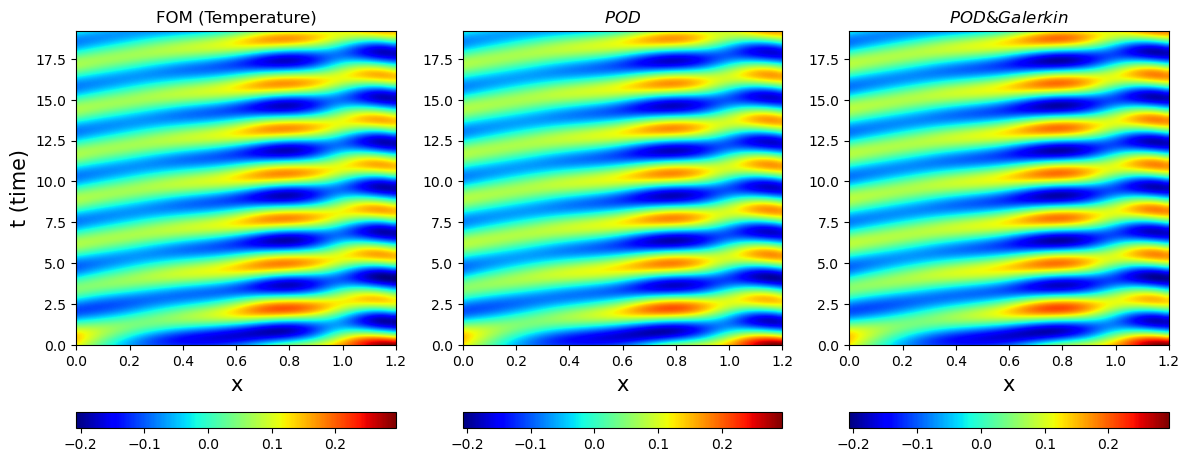

In [68]:
import matplotlib.pyplot as plt
import numpy as np


fig, ax = plt.subplots(1, 3, figsize=(12, 5))

# First subplot: T mean (WCE)
c1 = ax[0].imshow(T[:, :], aspect='auto', extent=[xO.min(), xO.max(), t.max(), t.min()], vmin=T.min(), vmax=T.max(), cmap='jet')
ax[0].set_xlabel('x', fontsize=15)
ax[0].set_ylabel('t (time)', fontsize=15)
ax[0].set_title('FOM (Temperature)')
ax[0].invert_yaxis()  # Invert y-axis to have time go from bottom to top
fig.colorbar(c1, ax=ax[0], orientation='horizontal')

# Second subplot: T mean (MC)
c2 = ax[1].imshow(T_R[:, :], aspect='auto', extent=[xO.min(), xO.max(), t.max(), t.min()], vmin=T.min(), vmax=T.max(),cmap='jet')
ax[1].set_xlabel('x', fontsize=15)
#ax[1].set_ylabel('T', fontsize=15)
ax[1].set_title('$POD$')
ax[1].invert_yaxis()  # Invert y-axis to have time go from bottom to top
fig.colorbar(c2, ax=ax[1], orientation='horizontal')

# Third subplot: L1 error
c3 = ax[2].imshow(T_G_R[:,:], aspect='auto', extent=[xO.min(), xO.max(), t.max(), t.min()],vmin=T.min(), vmax=T.max(), cmap='jet')
ax[2].set_xlabel('x', fontsize=15)
#ax[2].set_ylabel('T', fontsize=15)
ax[2].set_title('$POD&Galerkin$')
ax[2].invert_yaxis()  # Invert y-axis to have time go from bottom to top
fig.colorbar(c3, ax=ax[2], orientation='horizontal')


# Adjust layout
plt.tight_layout()
# Save the figure if needed
plt.savefig("POD_G_Temp_Reconstruction_2D_Paper1.png")

plt.show()


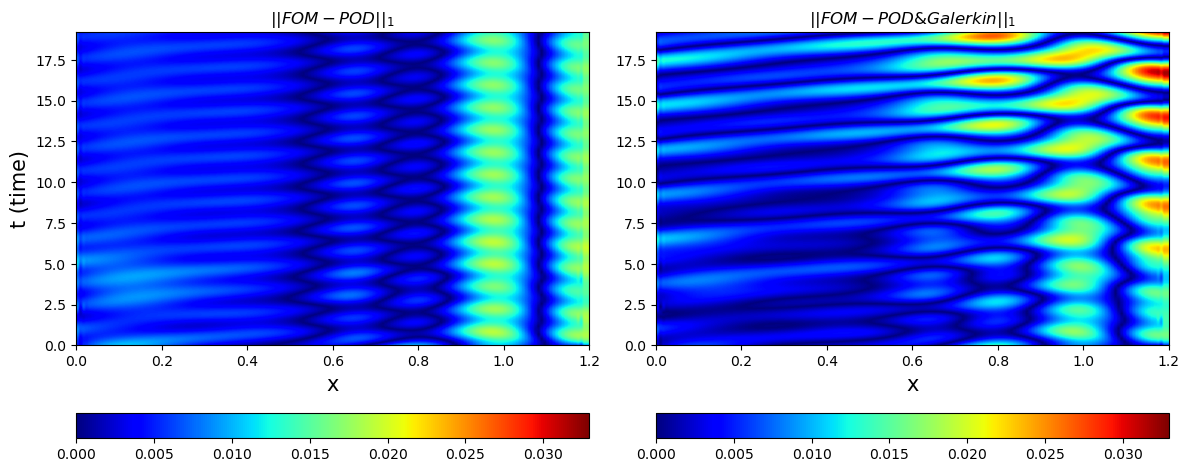

In [69]:
import matplotlib.pyplot as plt
import numpy as np


fig, ax = plt.subplots(1, 2, figsize=(12, 5))

c3 = ax[0].imshow(np.abs(T[:, :] - T_R[:, :]), aspect='auto', extent=[xO.min(), xO.max(), t.max(), t.min()], vmin=0, vmax=np.abs(T[:, :] - T_G_R[:, :]).max(),cmap='jet')
ax[0].set_xlabel('x', fontsize=15)
ax[0].set_ylabel('t (time)', fontsize=15)
ax[0].set_title('$||FOM-POD||_1$')
ax[0].invert_yaxis()  # Invert y-axis to have time go from bottom to top
fig.colorbar(c4, ax=ax[0], orientation='horizontal')



c5 = ax[1].imshow(np.abs(T[:, :] - T_G_R[:, :]), aspect='auto', extent=[xO.min(), xO.max(), t.max(), t.min()],vmin=0, vmax=np.abs(T[:, :] - T_G_R[:, :]).max(), cmap='jet')
ax[1].set_xlabel('x', fontsize=15)
#ax[4].set_ylabel('T', fontsize=15)
ax[1].set_title('$||FOM-POD&Galerkin||_1$')
ax[1].invert_yaxis()  # Invert y-axis to have time go from bottom to top
fig.colorbar(c5, ax=ax[1], orientation='horizontal')

# Adjust layout
plt.tight_layout()
# Save the figure if needed
plt.savefig("POD_G_Temp_Reconstruction_2D_Paper2.png")

plt.show()

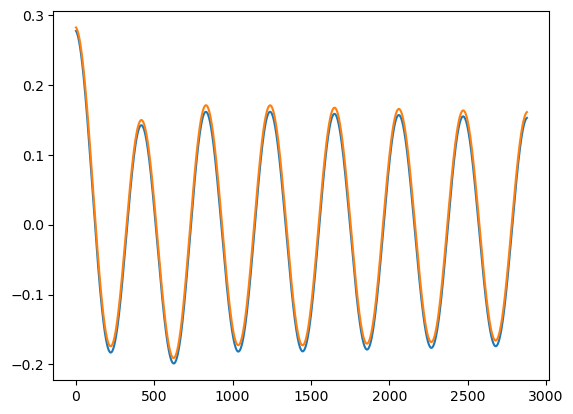

In [77]:
plt.plot(T[:, 158])
plt.plot(T_R[:, 158])

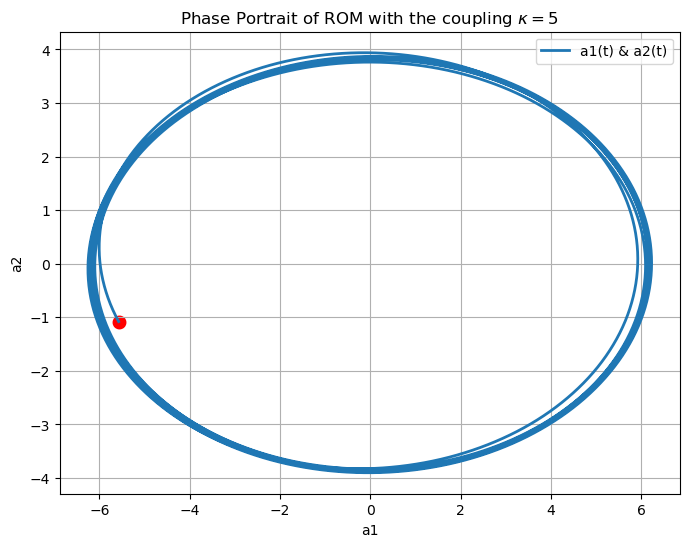

In [70]:
# Plot the results
plt.figure(figsize=(8, 6))
plt.plot(solutions_G.y[0,:], solutions_G.y[1,:], linewidth=2, label='a1(t) & a2(t)')
plt.scatter(solutions_G.y[0,0], solutions_G.y[1,0], linewidth=4, color='red')

plt.legend()
plt.xlabel('a1')
plt.ylabel('a2')
plt.grid()
plt.title('Phase Portrait of ROM with the coupling $\kappa = 5$')
#plt.savefig("ROM_Phase_Plot1.png", dpi=300)
plt.show()

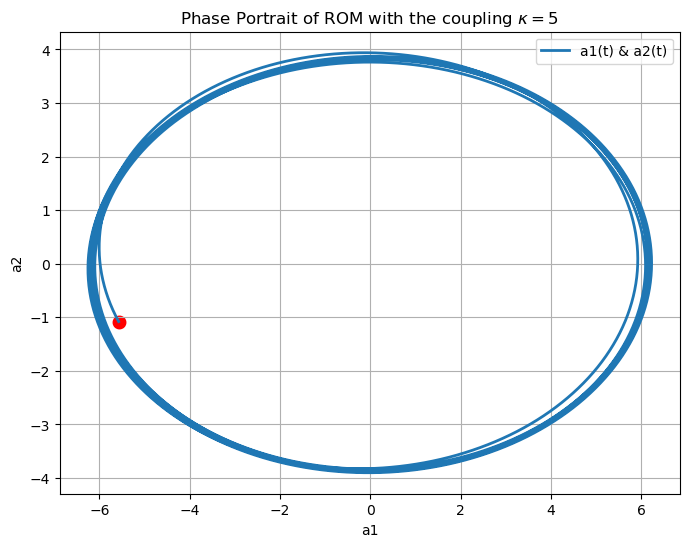

In [71]:
# Plot the results
plt.figure(figsize=(8, 6))
plt.plot(solutions_G.y[0,:], solutions_G.y[1,:], linewidth=2, label='a1(t) & a2(t)')
plt.scatter(solutions_G.y[0,0], solutions_G.y[1,0], linewidth=4, color='red')

plt.legend()
plt.xlabel('a1')
plt.ylabel('a2')
plt.grid()
plt.title('Phase Portrait of ROM with the coupling $\kappa = 5$')
#plt.savefig("ROM_Phase_Plot1.png", dpi=300)
plt.show()